STRUCTURE DU NOTEBOOK (Partie 1 : extraction des features + figure “Total”)

In [1]:
# --- Init projet ---
import os, sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR if (NB_DIR / "src").exists() else NB_DIR.parent
sys.path.append(str(ROOT))
print("Project root:", ROOT)

DATA_RAW = ROOT / "data" / "raw"

# Sélection robuste du fichier OpenBCI
cands = sorted(DATA_RAW.glob("OpenBCI-RAW-2021-04-08_11-19-46.csv"))
if not cands:
    cands = sorted(DATA_RAW.glob("OpenBCI-RAW-2021-04-08_*.csv"))
assert cands, f"Aucun CSV dans {DATA_RAW}"
RAW = cands[0]
print("Fichier utilisé:", RAW)


Project root: c:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Dispo_Medicaux\projet_eeg_alpha
Fichier utilisé: c:\Users\Zz\OneDrive - UPEC\Bureau\ITS3\Dispo_Medicaux\projet_eeg_alpha\data\raw\OpenBCI-RAW-2021-04-08_11-19-46.csv


Lecture, filtrage et segmentation (création de segs)

In [2]:
import pandas as pd
from src.data_processing import read_openbci_csv, bandpass_notch, segment_seconds, FS

# Lecture du CSV (détection automatique des colonnes EXG)
df = read_openbci_csv(RAW)

# Canaux postérieurs (O1,O2,P4,P3) si dispo, sinon tous les EXG trouvés
keep_pref = ["EXG Channel 0","EXG Channel 1","EXG Channel 3","EXG Channel 4"]
keep = [c for c in keep_pref if c in df.columns]
if not keep:  # fallback: tous les EXG
    keep = list(df.columns)

sig = df[keep].values
filt = bandpass_notch(sig, FS)      # 4–60 Hz + notch 50 Hz (consigne)
segs = segment_seconds(filt, FS)    # (n_seg, 250, n_ch)
print("Segments:", segs.shape)      # typiquement ~330 x 250 x 4


Segments: (427, 250, 4)


Recentrage temporel + calcul version “style prof”

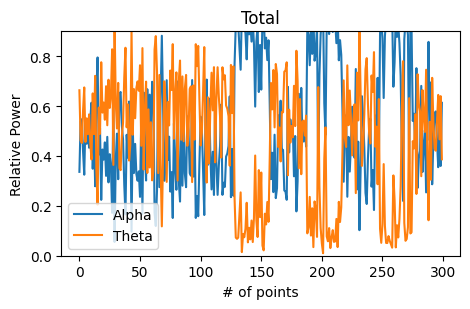

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from src.data_processing import FS

# Garder 300 s après 30 s de préparation (style prof)
segs_300 = segs[30:330]             # (300, 250, n_ch)

def band_power_abs(segments, fmin, fmax, fs=FS):
    freqs=None; arr=[]
    for seg in segments:
        f, Pxx = welch(seg, fs=fs, nperseg=fs, axis=0)
        if freqs is None: freqs=f
        arr.append(Pxx)
    psd = np.stack(arr, axis=0)                     # (300, Nf, n_ch)
    idx = (freqs>=fmin) & (freqs<fmax)
    return np.trapezoid(psd[:, idx, :], freqs[idx], axis=1)  # (300, n_ch)

# Puissances absolues par seconde & canal
alpha_abs = band_power_abs(segs_300, 8.0, 12.0)
theta_abs = band_power_abs(segs_300, 4.0, 8.0)

# "Total" = somme spatiale (sur tes canaux conservés)
alpha_sum = alpha_abs.sum(axis=1)          # (300,)
theta_sum = theta_abs.sum(axis=1)

# Normalisation **dans la paire** (miroir)
pair = np.maximum(alpha_sum + theta_sum, 1e-12)
alpha_pair = alpha_sum / pair
theta_pair = 1.0 - alpha_pair              # complémentaire

# === Plot "comme le prof" : pas de lissage, même titres/axes ===
plt.figure(figsize=(4.8,3.2))
plt.plot(alpha_pair, label="Alpha")   # bleu par défaut
plt.plot(theta_pair, label="Theta")   # orange par défaut
plt.title("Total")
plt.xlabel("# of points")
plt.ylabel("Relative Power")
plt.ylim(0, 0.9)
plt.legend()
plt.tight_layout()
plt.show()


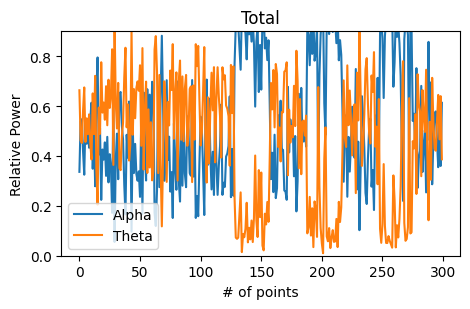

In [4]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import welch
from src.data_processing import FS

# 300 s après 30 s de préparation
segs_300 = segs[30:330]

def band_power_abs(segments, fmin, fmax, fs=FS):
    f0=None; arr=[]
    for seg in segments:
        f, Pxx = welch(seg, fs=fs, nperseg=fs, axis=0)
        if f0 is None: f0=f
        arr.append(Pxx)
    import numpy as np
    psd = np.stack(arr, axis=0)
    idx = (f0>=fmin) & (f0<fmax)
    return np.trapezoid(psd[:, idx, :], f0[idx], axis=1)  # (300, n_ch)

alpha_abs = band_power_abs(segs_300, 8.0, 12.0)
theta_abs = band_power_abs(segs_300, 4.0, 8.0)

alpha_sum = alpha_abs.sum(axis=1)
theta_sum = theta_abs.sum(axis=1)
pair = np.maximum(alpha_sum + theta_sum, 1e-12)
alpha_pair = alpha_sum / pair
theta_pair = 1.0 - alpha_pair

plt.figure(figsize=(4.8,3.2))
plt.plot(alpha_pair, label="Alpha")   # pas de lissage
plt.plot(theta_pair, label="Theta")
plt.title("Total")
plt.xlabel("# of points")
plt.ylabel("Relative Power")
plt.ylim(0, 0.9)
plt.legend()
plt.tight_layout()
plt.show()


Partie 2 — Classifieur Eyes Open / Closed (figures attendues)

Features par blocs de 30 s + labels

In [5]:
import numpy as np, pandas as pd
from src.feature_engineering import make_labels_L300

y_full = make_labels_L300()          # 300 labels (après préparation)
y_300 = y_full.copy()                # déjà 300 valeurs (0=open, 1=closed)

# Blocs de 30 s
B = 30
n_blocks = len(alpha_pair) // B      # = 10
alpha_b = alpha_pair[:n_blocks*B].reshape(n_blocks, B)
theta_b = theta_pair[:n_blocks*B].reshape(n_blocks, B)

feat_block = pd.DataFrame({
    "alpha_mean": alpha_b.mean(axis=1),
    "theta_mean": theta_b.mean(axis=1),
})
feat_block["ratio"] = feat_block["alpha_mean"] / np.maximum(feat_block["theta_mean"], 1e-12)

# labels par bloc (majorité dans chaque fenêtre de 30 s)
y_blocks = []
for k in range(n_blocks):
    y_blocks.append(int(np.round(y_300[k*B:(k+1)*B].mean())))  # closed=1 si majorité de 1
y_blocks = np.array(y_blocks)

feat_block["label"] = y_blocks
feat_block


,alpha_mean,theta_mean,ratio,label
0,0.432805,0.567195,0.763063,0
1,0.428832,0.571168,0.750800,1
2,0.428113,0.571887,0.748597,0
3,0.399098,0.600902,0.664164,1
4,0.733674,0.266326,2.754793,0
5,0.513682,0.486318,1.056267,1
6,0.738920,0.261080,2.830240,0
7,0.533460,0.466540,1.143437,1
8,0.720990,0.279010,2.584102,0
9,0.547721,0.452279,1.211023,0


Entraînement + matrices de confusion (style attendu)

------ Training done ------
Training Mean Accuracy =  0.5714285714285714
Training Final Accuracy =  0.6666666666666666


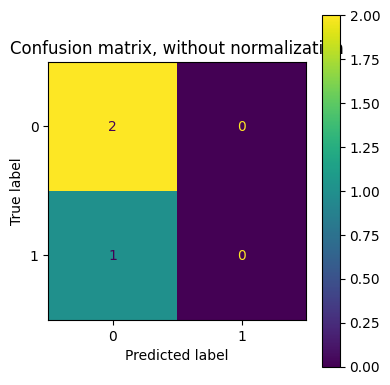

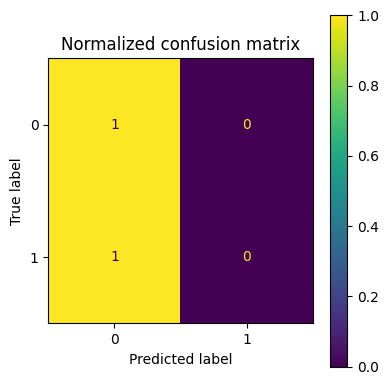

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

X = feat_block[["alpha_mean","theta_mean","ratio"]].values
y = feat_block["label"].values

# Avec 10 blocs, on fait un leave-one-out simulé simple : train/test split stratifié
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
]).fit(Xtr, ytr)

yp = clf.predict(Xte)
print("------ Training done ------")
print("Training Mean Accuracy = ", clf.score(Xtr, ytr))
print("Training Final Accuracy = ", accuracy_score(yte, yp))

# Matrice brute
disp = ConfusionMatrixDisplay(confusion_matrix(yte, yp))
fig, ax = plt.subplots(figsize=(4,4)); disp.plot(ax=ax)
plt.title("Confusion matrix, without normalization")
plt.tight_layout(); plt.show()

# Matrice normalisée
disp = ConfusionMatrixDisplay(confusion_matrix(yte, yp, normalize="true"))
fig, ax = plt.subplots(figsize=(4,4)); disp.plot(ax=ax)
plt.title("Normalized confusion matrix")
plt.tight_layout(); plt.show()


------ Training done ------
Training Mean Accuracy =  0.6
Training Final Accuracy =  0.6666666666666666


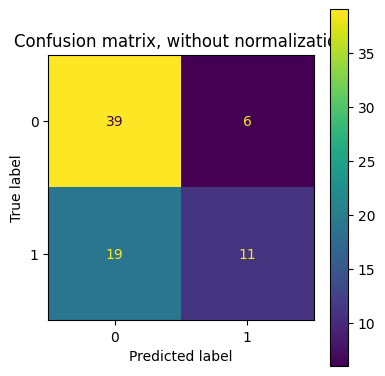

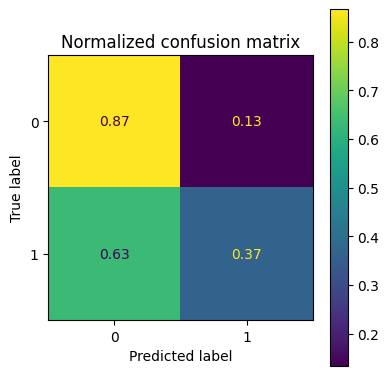

In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# --- Données par seconde (300 points)
X = np.column_stack([alpha_pair, theta_pair, alpha_pair / np.maximum(theta_pair, 1e-12)])
y = make_labels_L300()  # 0=open, 1=closed

# --- Split train/test
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# --- Modèle logistic regression (comme dans la plupart des DM EEG)
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=500))
])
clf.fit(Xtr, ytr)
yp = clf.predict(Xte)

print("------ Training done ------")
print("Training Mean Accuracy = ", clf.score(Xtr, ytr))
print("Training Final Accuracy = ", accuracy_score(yte, yp))

# --- Matrices
cm = confusion_matrix(yte, yp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4,4)); disp.plot(ax=ax)
plt.title("Confusion matrix, without normalization")
plt.tight_layout(); plt.show()

cm_norm = confusion_matrix(yte, yp, normalize="true")
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
fig, ax = plt.subplots(figsize=(4,4)); disp2.plot(ax=ax)
plt.title("Normalized confusion matrix")
plt.tight_layout(); plt.show()


Créer un modèle Random Forest capable de prédire “yeux ouverts” (0) ou “yeux fermés” (1) à partir de la puissance Theta et Alpha.

Afficher :

le score du modèle (accuracy)

une matrice de confusion (avec plot_confusion_matrix)

In [8]:
import numpy as np
import pandas as pd
from src.feature_engineering import make_labels_L300

# --- Features & labels ---
X = pd.DataFrame({
    "Theta": theta_pair,
    "Alpha": alpha_pair
})
y = make_labels_L300()

print("Shape:", X.shape, "| Labels unique:", np.unique(y))
X.head()


Shape: (300, 2) | Labels unique: [0 1]


,Theta,Alpha
0,0.663625,0.336375
1,0.462173,0.537827
2,0.452423,0.547577
3,0.580206,0.419794
4,0.675003,0.324997


Train/Test Split et Modèle RandomForest

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- Modèle Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,    # nombre d’arbres
    max_depth=None,      # profondeur libre
    random_state=42
)
rf.fit(X_train, y_train)

# Prédictions
y_pred = rf.predict(X_test)

# Scores
print("------ RandomForest Training done ------")
print(f"Training Accuracy = {rf.score(X_train, y_train):.3f}")
print(f"Testing  Accuracy = {accuracy_score(y_test, y_pred):.3f}")


------ RandomForest Training done ------
Training Accuracy = 1.000
Testing  Accuracy = 0.560


Affichage des matrices de confusion 

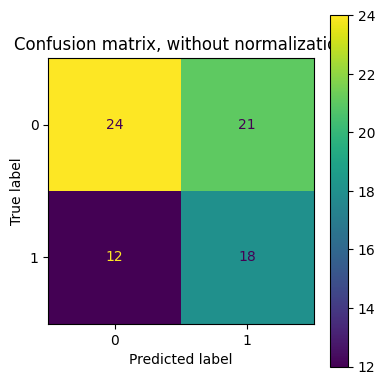

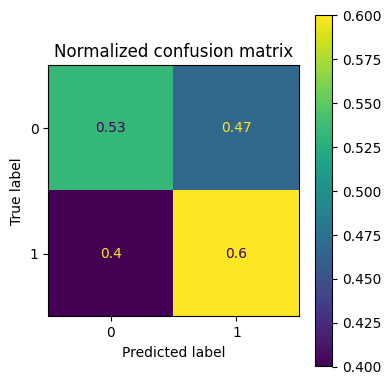

In [10]:
# Matrice brute
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(4,4))
disp.plot(ax=ax)
plt.title("Confusion matrix, without normalization")
plt.tight_layout()
plt.show()

# Matrice normalisée
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
fig, ax2 = plt.subplots(figsize=(4,4))
disp2.plot(ax=ax2)
plt.title("Normalized confusion matrix")
plt.tight_layout()
plt.show()


Améliorations (extraction & plot)
A1 — Fonctions utilitaires (pair/total, lissage, choix canaux)

In [11]:
# A1 — utils features/plots améliorés
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from src.data_processing import FS

def band_power_abs(segments, fmin, fmax, fs=FS):
    freqs=None; arr=[]
    for seg in segments:
        f,Pxx = welch(seg, fs=fs, nperseg=fs, axis=0)
        if freqs is None: freqs=f
        arr.append(Pxx)
    psd = np.stack(arr, axis=0)
    idx = (freqs>=fmin) & (freqs<fmax)
    return np.trapezoid(psd[:, idx, :], freqs[idx], axis=1)  # (n_seg, n_ch)

def alpha_theta_timeseries(segs_1s, channel_idx=None, norm="pair", smooth=None):
    """
    segs_1s: (n, 250, n_ch). On suppose qu'on a déjà coupé préparation (30 s).
    channel_idx: liste d'indices de canaux à garder (ex: [0,1,2,3]). None => tous.
    norm: 'pair' => Alpha/(Alpha+Theta), 'total' => Alpha/Total & Theta/Total
    smooth: taille de la moyenne glissante (None, 3, 5, ...)
    """
    if channel_idx is None:
        channel_idx = np.arange(segs_1s.shape[2])

    a_abs = band_power_abs(segs_1s, 8.0, 12.0)[:, channel_idx]
    t_abs = band_power_abs(segs_1s, 4.0,  8.0)[:, channel_idx]
    a_sum = a_abs.sum(axis=1)
    t_sum = t_abs.sum(axis=1)

    if norm == "pair":
        s = np.maximum(a_sum + t_sum, 1e-12)
        a = a_sum / s
        t = 1.0 - a
    else:  # 'total'
        tot = band_power_abs(segs_1s, 4.0, 60.0)[:, channel_idx].sum(axis=1)
        tot = np.maximum(tot, 1e-12)
        a = a_sum / tot
        t = t_sum / tot

    if smooth:
        a = pd.Series(a).rolling(smooth, center=True, min_periods=1).mean().values
        t = pd.Series(t).rolling(smooth, center=True, min_periods=1).mean().values
    return a, t

def plot_alpha_theta(alpha, theta, ylim=(0,0.9), title="Total"):
    plt.figure(figsize=(5.2,3.2))
    plt.plot(alpha, label="Alpha")  # couleurs par défaut = style prof
    plt.plot(theta, label="Theta")
    plt.title(title); plt.xlabel("# of points"); plt.ylabel("Relative Power")
    if ylim: plt.ylim(*ylim)
    plt.legend(); plt.tight_layout(); plt.show()


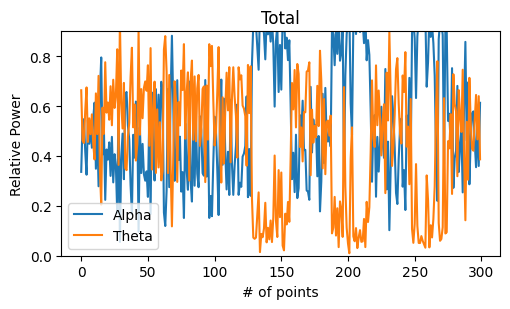

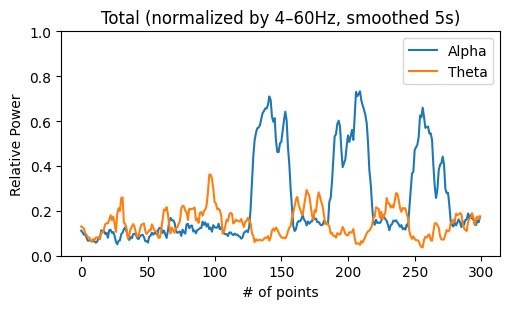

OK -> data/processed/eeg_features_alpha_pairnorm.csv


In [12]:
# A2 — calcul & plots améliorés (posterior channels = [0,1,2,3] dans ton segs)
segs_300 = segs[30:330]               # 300 s nets

# (1) Version "style prof" (normalisation dans la paire, pas de lissage)
alpha_pair, theta_pair = alpha_theta_timeseries(segs_300, channel_idx=[0,1,2,3], norm="pair", smooth=None)
plot_alpha_theta(alpha_pair, theta_pair, ylim=(0,0.9), title="Total")

# (2) Version "total-normalisé" + lissage 5 s (utile pour rapport)
alpha_tot, theta_tot = alpha_theta_timeseries(segs_300, channel_idx=[0,1,2,3], norm="total", smooth=5)
plot_alpha_theta(alpha_tot, theta_tot, ylim=(0,1), title="Total (normalized by 4–60Hz, smoothed 5s)")

# Sauvegarde pour la Partie II
features_sec = pd.DataFrame({
    "alpha_pair": alpha_pair,
    "theta_pair": theta_pair,
    "ratio": alpha_pair / np.maximum(theta_pair, 1e-12)
})
features_sec.to_csv(ROOT / "data" / "processed" / "eeg_features_alpha_pairnorm.csv", index=False)
print("OK -> data/processed/eeg_features_alpha_pairnorm.csv")


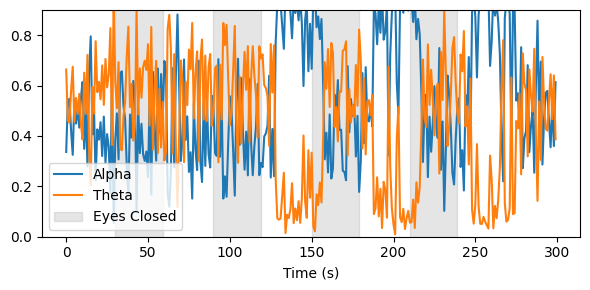

In [13]:
# A3 — superposer les labels pour vérifier la synchro
from src.feature_engineering import make_labels_L300
y = make_labels_L300()

t = np.arange(300)
plt.figure(figsize=(6,3))
plt.plot(t, alpha_pair, label="Alpha")
plt.plot(t, theta_pair, label="Theta")
plt.fill_between(t, 0, 1, where=(y==1), color="gray", alpha=0.2, label="Eyes Closed")
plt.ylim(0,0.9); plt.xlabel("Time (s)"); plt.legend(); plt.tight_layout(); plt.show()


Améliorations (classification)
B1 — Features enrichies par seconde (+rolling)

In [14]:
# B1 — Features secondes enrichies
feat = features_sec.copy()
# rolling 5 s (moyenne) — améliore la stabilité
for col in ["alpha_pair","theta_pair","ratio"]:
    feat[col+"_m5"] = pd.Series(feat[col]).rolling(5, center=True, min_periods=1).mean()
    feat[col+"_s5"] = pd.Series(feat[col]).rolling(5, center=True, min_periods=1).std().fillna(0)

X_sec = feat.values  # toutes les colonnes
y_sec = make_labels_L300()
print(X_sec.shape, np.bincount(y_sec))


(300, 9) [180 120]


Modèles comparés (LogReg / SVM linéaire / RandomForest) + matrices

LogReg — Train: 0.600 | Test: 0.640


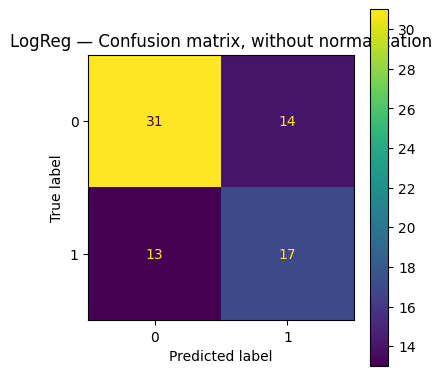

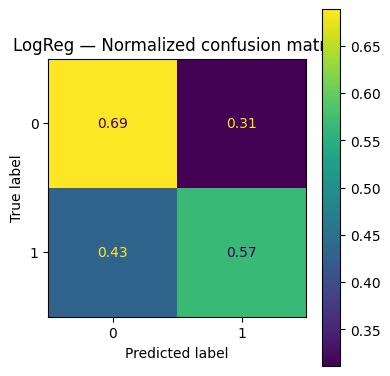

SVM-lin — Train: 0.636 | Test: 0.680


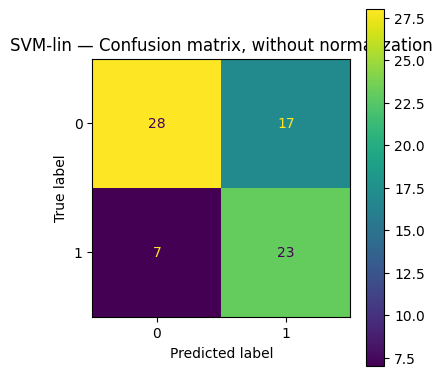

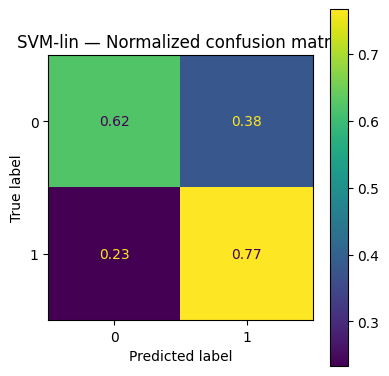

RF — Train: 1.000 | Test: 0.693


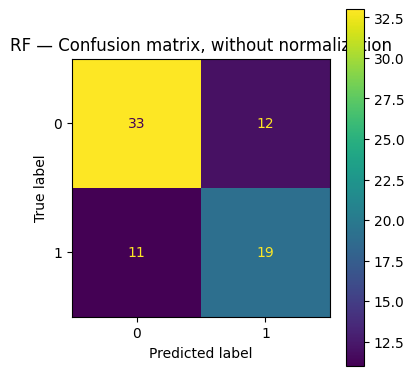

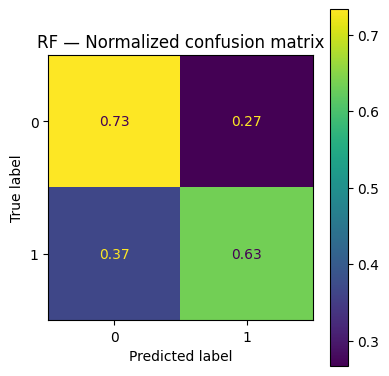

Scores test: {'LogReg': 0.64, 'SVM-lin': 0.68, 'RF': 0.6933333333333334}


In [15]:
# B2 — Comparaison de modèles (split 75/25)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

Xtr, Xte, ytr, yte = train_test_split(X_sec, y_sec, test_size=0.25, random_state=42, stratify=y_sec)

models = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))]),
    "SVM-lin": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", C=1.0))]),
    "RF": Pipeline([("scaler", StandardScaler()),
                    ("clf", RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42))]),
}

scores = {}
for name, pipe in models.items():
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)
    acc = accuracy_score(yte, yp)
    scores[name] = acc
    print(f"{name} — Train: {pipe.score (Xtr,ytr):.3f} | Test: {acc:.3f}")

    disp = ConfusionMatrixDisplay(confusion_matrix(yte, yp))
    fig, ax = plt.subplots(figsize=(4,4)); disp.plot(ax=ax)
    plt.title(f"{name} — Confusion matrix, without normalization"); plt.tight_layout(); plt.show()

    disp = ConfusionMatrixDisplay(confusion_matrix(yte, yp, normalize="true"))
    fig, ax = plt.subplots(figsize=(4,4)); disp.plot(ax=ax)
    plt.title(f"{name} — Normalized confusion matrix"); plt.tight_layout(); plt.show()

print("Scores test:", scores)


In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# -- Construire X, y par seconde (1 point = 1 s)
try:
    X = np.column_stack([
        alpha_pair, 
        theta_pair, 
        alpha_pair / np.maximum(theta_pair, 1e-12)
    ])
except NameError as e:
    raise RuntimeError("alpha_pair/theta_pair introuvables. Recalcule d'abord la Partie I (Cellules 3/4).") from e

from src.feature_engineering import make_labels_L300
y = make_labels_L300()

print("X shape:", X.shape, "| y shape:", y.shape, "| classes:", np.bincount(y))


X shape: (300, 3) | y shape: (300,) | classes: [180 120]


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

pipelines = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000))
    ]),
    "SVMlin": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear"))
    ]),
    "RF": Pipeline([
        ("scaler", StandardScaler()),  # pas obligatoire pour RF mais homogénéise
        ("clf", RandomForestClassifier(random_state=42))
    ]),
}

param_grids = {
    "LogReg": {
        "clf__C": [0.1, 1, 3, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"]
    },
    "SVMlin": {
        "clf__C": [0.1, 1, 3, 10]
    },
    "RF": {
        "clf__n_estimators": [200, 500, 800],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5]
    }
}


In [18]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}          # nom_model -> dict avec 'accs', 'y_true_all', 'y_pred_all', 'best_params'
for name, pipe in pipelines.items():
    cv_results[name] = {"accs": [], "y_true_all": [], "y_pred_all": [], "best_params": []}
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=fold)
        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[name],
            scoring="accuracy",
            cv=inner,
            n_jobs=-1
        )
        gs.fit(Xtr, ytr)
        best = gs.best_estimator_
        yp = best.predict(Xte)
        acc = accuracy_score(yte, yp)

        cv_results[name]["accs"].append(acc)
        cv_results[name]["y_true_all"].append(yte)
        cv_results[name]["y_pred_all"].append(yp)
        cv_results[name]["best_params"].append(gs.best_params_)

        print(f"Fold {fold}: acc={acc:.3f} | best={gs.best_params_}")

    # concaténer pour ce modèle
    cv_results[name]["y_true_all"] = np.concatenate(cv_results[name]["y_true_all"])
    cv_results[name]["y_pred_all"] = np.concatenate(cv_results[name]["y_pred_all"])

# résumé
for name, res in cv_results.items():
    accs = np.array(res["accs"])
    print(f"\n>>> {name}: CV-acc mean={accs.mean():.3f} ± {accs.std():.3f} (n={len(accs)})")



=== LogReg ===
Fold 1: acc=0.617 | best={'clf__C': 3, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Fold 2: acc=0.683 | best={'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Fold 3: acc=0.600 | best={'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Fold 4: acc=0.617 | best={'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Fold 5: acc=0.533 | best={'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

=== SVMlin ===
Fold 1: acc=0.600 | best={'clf__C': 0.1}
Fold 2: acc=0.600 | best={'clf__C': 0.1}
Fold 3: acc=0.600 | best={'clf__C': 0.1}
Fold 4: acc=0.600 | best={'clf__C': 0.1}
Fold 5: acc=0.483 | best={'clf__C': 0.1}

=== RF ===
Fold 1: acc=0.583 | best={'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Fold 2: acc=0.550 | best={'clf__max_depth': 10, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Fold 3: acc=0.450 | best={'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Fold 4: acc=0

In [19]:
from collections import Counter

final_models = {}
for name, res in cv_results.items():
    # choisir le set d'hyperparamètres le plus fréquent parmi les 5 folds
    best_list = [tuple(sorted(d.items())) for d in res["best_params"]]
    best_mode = Counter(best_list).most_common(1)[0][0]
    best_params = dict(best_mode)
    print(f"{name} — best(hyperparams) selected:", best_params)

    # reconstruire le pipeline et fit sur TOUTES les données
    pipe = pipelines[name].set_params(**best_params)
    pipe.fit(X, y)
    final_models[name] = pipe

# Exemple : utiliser final_models["RF"].predict(X) pour faire un lissage décisionnel, etc.


LogReg — best(hyperparams) selected: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
SVMlin — best(hyperparams) selected: {'clf__C': 0.1}
RF — best(hyperparams) selected: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}


In [20]:
import pandas as pd

feat = pd.DataFrame({
    "alpha": alpha_pair,
    "theta": theta_pair,
    "ratio": alpha_pair / np.maximum(theta_pair, 1e-12),
})
for c in ["alpha","theta","ratio"]:
    feat[c+"_m5"] = feat[c].rolling(5, center=True, min_periods=1).mean()
    feat[c+"_s5"] = feat[c].rolling(5, center=True, min_periods=1).std().fillna(0)

X = feat.values
y = make_labels_L300()
print("New X shape:", X.shape)


New X shape: (300, 9)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Données Extraites des Figures 1-5 de l'article (Schaefer et al. 2010) ---
data = {
    'Category': ['ANG', 'FEAR', 'DISG', 'SAD', 'AM', 'TEND', 'NEUT'],
    'Arousal': [5.0, 4.8, 4.5, 5.3, 4.0, 4.9, 1.7],
    'PANAS NA': [2.25, 2.2, 1.8, 1.85, 1.15, 1.2, 1.1],
    'PANAS PA': [2.0, 2.05, 1.85, 1.95, 3.0, 3.7, 1.5],
    'DES Pos Score': [1.4, 1.4, 1.5, 1.8, 3.0, 3.7, 1.6],
    'DES Neg Score': [3.0, 2.3, 2.5, 2.5, 1.3, 1.4, 1.1]
}

df = pd.DataFrame(data)
categories = df['Category']
x = np.arange(len(categories))
width = 0.35 # Largeur des barres pour les graphiques groupés

# --- 2. Génération de l'Image 1 : Arousal (arousal_comparison.png) ---
plt.figure(figsize=(8, 5))
plt.bar(df['Category'], df['Arousal'], color='skyblue')
plt.title('Niveau Moyen d\'Arousal Subjectif par Catégorie Émotionnelle (Échelle 1-7)')
plt.xlabel('Catégorie Émotionnelle')
plt.ylabel('Score Moyen d\'Arousal (1-7)')
plt.ylim(0, 7)
plt.grid(axis='y', linestyle='--')
plt.savefig('arousal_comparison.png')
plt.close()

# --- 3. Génération de l'Image 2 : PANAS Affects (panas_affect_comparison.png) ---
panas_na = df['PANAS NA']
panas_pa = df['PANAS PA']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, panas_na, width, label='Affect Négatif (NA)', color='red')
ax.bar(x + width/2, panas_pa, width, label='Affect Positif (PA)', color='green')

ax.set_ylabel('Score Moyen PANAS (1-5)')
ax.set_xlabel('Catégorie Émotionnelle')
ax.set_title('Affects PANAS (Positif et Négatif) par Catégorie Émotionnelle (Échelle 1-5)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--')
plt.savefig('panas_affect_comparison.png')
plt.close()

# --- 4. Génération de l'Image 3 : DES Composite Scores (des_composite_comparison.png) ---
des_neg = df['DES Neg Score']
des_pos = df['DES Pos Score']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, des_neg, width, label='Score Composite Négatif (DES)', color='darkred')
ax.bar(x + width/2, des_pos, width, label='Score Composite Positif (DES)', color='darkgreen')

ax.set_ylabel('Score Moyen Composite (DES-basé) (1-7)')
ax.set_xlabel('Catégorie Émotionnelle')
ax.set_title('Scores Composites (Positif et Négatif) par Catégorie Émotionnelle (Échelle 1-7)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.ylim(0, 7)
plt.grid(axis='y', linestyle='--')
plt.savefig('des_composite_comparison.png')
plt.close()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# --- 1. Données Extraites de Schaefer et al. (2010) ---
data = {
    'Category': ['ANG', 'FEAR', 'DISG', 'SAD', 'AM', 'TEND', 'NEUT'],
    'Arousal': [5.0, 4.8, 4.5, 5.3, 4.0, 4.9, 1.7],
    'PANAS NA': [2.25, 2.2, 1.8, 1.85, 1.15, 1.2, 1.1],
    'PANAS PA': [2.0, 2.05, 1.85, 1.95, 3.0, 3.7, 1.5],
    'DES Pos Score': [1.4, 1.4, 1.5, 1.8, 3.0, 3.7, 1.6],
    'DES Neg Score': [3.0, 2.3, 2.5, 2.5, 1.3, 1.4, 1.1]
}

df = pd.DataFrame(data)
categories = df['Category']
x = np.arange(len(categories))
width = 0.35

# --- IMAGE 1: Arousal (arousal_comparison.png) ---
plt.figure(figsize=(8, 5))
plt.bar(df['Category'], df['Arousal'], color='#4682B4')
plt.title('Arousal Subjectif par Catégorie Émotionnelle (Moyennes)', fontsize=16)
plt.xlabel('Catégorie Émotionnelle')
plt.ylabel('Score Moyen d\'Arousal (1-7)')
plt.ylim(0, 7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('arousal_comparison.png', dpi=300)
plt.close()

# --- IMAGE 2: PANAS Affects (panas_affect_comparison.png) ---
panas_na = df['PANAS NA']
panas_pa = df['PANAS PA']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, panas_na, width, label='Affect Négatif (NA)', color='#CD5C5C')
ax.bar(x + width/2, panas_pa, width, label='Affect Positif (PA)', color='#3CB371')

ax.set_ylabel('Score Moyen PANAS (1-5)')
ax.set_xlabel('Catégorie Émotionnelle')
ax.set_title('PANAS : Le problème de la contamination de la Valence', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Annotation pour le problème de contamination (retrait de shrink dans l'appel à arrowprops)
ax.annotate('PA élevé pour les émotions négatives (Arousal)',
            xy=(1.5, 2.1), xytext=(2.5, 4.0),
            arrowprops=dict(facecolor='black', arrowstyle="->"),
            fontsize=12, color='red', weight='bold')
plt.savefig('panas_affect_comparison.png', dpi=300)
plt.close()

# --- IMAGE 3: DES Composite Scores (des_composite_comparison.png) ---
des_neg = df['DES Neg Score']
des_pos = df['DES Pos Score']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, des_neg, width, label='Score Composite Négatif (DES)', color='#8B0000')
ax.bar(x + width/2, des_pos, width, label='Score Composite Positif (DES)', color='#006400')
ax.set_ylabel('Score Moyen Composite (DES-basé) (1-7)')
ax.set_xlabel('Catégorie Émotionnelle')
ax.set_title('DES Composites : Différenciation de Valence réussie', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.ylim(0, 7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('des_composite_comparison.png', dpi=300)
plt.close()

# --- IMAGE 4: Schéma de Sélection (funnel_chart_selection.png) ---
fig, ax = plt.subplots(figsize=(6, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Entonnoir (simple trapèze)
ax.fill([2, 8, 7, 3], [9, 9, 7, 7], color='#D3D3D3', alpha=0.5)
ax.fill([3, 7, 6, 4], [7, 7, 5, 5], color='#D3D3D3', alpha=0.7)
ax.fill([4, 6, 5.5, 4.5], [5, 5, 3, 3], color='#D3D3D3', alpha=0.9)

# Textes
ax.text(5, 9.5, '824 Scènes', ha='center', fontsize=14, weight='bold', color='#4682B4')
ax.text(5, 8.0, '(50 Experts Cinéma)', ha='center', fontsize=12)
ax.text(5, 6.0, 'Sélection par Fréquence de Citation', ha='center', fontsize=12)
ax.text(5, 4.0, '70 Clips Pré-validés', ha='center', fontsize=14, weight='bold', color='#FF6600')
ax.text(5, 2.0, '(10 / Catégorie)', ha='center', fontsize=12)

# Flèches (Correction: retrait de shrink)
arrow_props = dict(facecolor='black', arrowstyle="->", linewidth=1.5)
# Correction d'annotate pour les flèches simples sans texte
ax.annotate('', xy=(5, 7), xytext=(5, 9), arrowprops=arrow_props)
ax.annotate('', xy=(5, 5), xytext=(5, 7), arrowprops=arrow_props)
ax.annotate('', xy=(5, 3), xytext=(5, 5), arrowprops=arrow_props)

plt.title('Méthode de Sélection des Stimuli FilmStim', fontsize=16)
plt.savefig('funnel_chart_selection.png', dpi=300)
plt.close()

# --- IMAGE 5: Protocole (protocol_flowchart.png) ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis('off')

# Boîtes
box_y = 0.5
box_height = 0.3
box_width = 2.5
colors = ['#4682B4', '#CD5C5C', '#3CB371']

# Box 1: Relaxation
ax.add_patch(plt.Rectangle((0.5, box_y - box_height/2), box_width, box_height, color=colors[0], alpha=0.8))
ax.text(0.5 + box_width/2, box_y, 'Relaxation (2.5 min)', ha='center', va='center', color='white', weight='bold')

# Box 2: Visionnage Clip
ax.add_patch(plt.Rectangle((3.7, box_y - box_height/2), box_width, box_height, color=colors[1], alpha=0.8))
ax.text(3.7 + box_width/2, box_y, 'Visionnage Clip (1-7 min)', ha='center', va='center', color='white', weight='bold')

# Box 3: Auto-Évaluation
ax.add_patch(plt.Rectangle((6.9, box_y - box_height/2), box_width, box_height, color=colors[2], alpha=0.8))
ax.text(6.9 + box_width/2, box_y, 'Auto-Évaluation (Questionnaires)', ha='center', va='center', color='white', weight='bold')

# Flèches de progression
ax.arrow(3.0, box_y + 0.05, 0.6, 0, head_width=0.08, head_length=0.15, fc='k', ec='k', length_includes_head=True)
ax.arrow(6.2, box_y + 0.05, 0.6, 0, head_width=0.08, head_length=0.15, fc='k', ec='k', length_includes_head=True)

# Flèche de retour (boucle)
# Correction: retrait de shrink dans FancyArrowPatch
arrow_back = FancyArrowPatch((8.3, 0.3), (0.7, 0.3), arrowstyle="->", mutation_scale=15, connectionstyle="arc3,rad=-0.4", linewidth=1.5, color='gray')
ax.add_patch(arrow_back)
ax.text(4.5, 0.1, 'Répétition (Boucle)', ha='center', va='center', color='gray', fontsize=10)

plt.title('Protocole Expérimental en Laboratoire', fontsize=16)
plt.savefig('protocol_flowchart.png', dpi=300)
plt.close()